In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('Telco_Customer_Churn.csv')

# --- DATA CLEANING ---

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



*   Checked for blank strings in all object columns.
*   Replaced the found blank strings with NaN values.
*   Dropped the rows with NaN values instead of imputing as there were only 11 such rows.
*   Fixed the data type of the TotalCharges feature, i.e, converted it from object type to float.


In [ ]:
obj_cols = df.select_dtypes(include="object").columns

for col in obj_cols:
    blanks = (df[col].str.strip() == "").sum()
    if blanks > 0:
        print(col, blanks)

TotalCharges 11


In [ ]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", pd.NA)

In [ ]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,<NA>
753,0,20.25,<NA>
936,0,80.85,<NA>
1082,0,25.75,<NA>
1340,0,56.05,<NA>
3331,0,19.85,<NA>
3826,0,25.35,<NA>
4380,0,20.00,<NA>
5218,0,19.70,<NA>
6670,0,73.35,<NA>


In [ ]:
df[df["tenure"] == 0]["TotalCharges"].isna().sum()

np.int64(11)

In [ ]:
df = df.dropna(subset=["TotalCharges"])

In [ ]:
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [ ]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

Saved customerID for reference and dropped it from the dataframe as it is not required for eda, segmentation or churn modeling.

In [ ]:
customer_ids = df["customerID"]
df = df.drop(columns=["customerID"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [ ]:
for col in df.select_dtypes(include="object").columns:
    print(col)
    print(df[col].unique())

gender
['Female' 'Male']
Partner
['Yes' 'No']
Dependents
['No' 'Yes']
PhoneService
['No' 'Yes']
MultipleLines
['No phone service' 'No' 'Yes']
InternetService
['DSL' 'Fiber optic' 'No']
OnlineSecurity
['No' 'Yes' 'No internet service']
OnlineBackup
['Yes' 'No' 'No internet service']
DeviceProtection
['No' 'Yes' 'No internet service']
TechSupport
['No' 'Yes' 'No internet service']
StreamingTV
['No' 'Yes' 'No internet service']
StreamingMovies
['No' 'Yes' 'No internet service']
Contract
['Month-to-month' 'One year' 'Two year']
PaperlessBilling
['Yes' 'No']
PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn
['No' 'Yes']


# --- EDA ---

### Target Variable Distribution (Churn)

In [ ]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


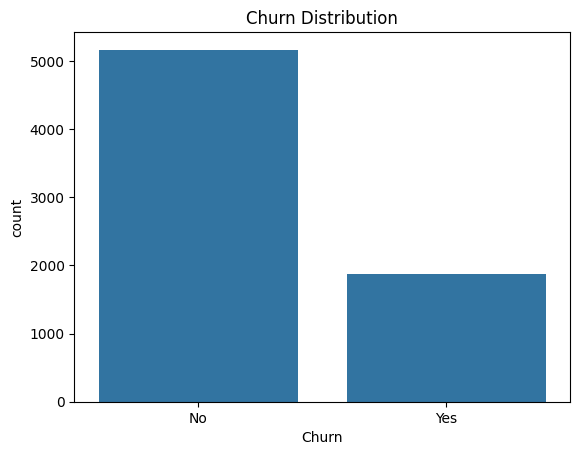

In [ ]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

In [ ]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[num_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


*   25% customers churn within the first 9 months.
*   The first year has the highest churn risk.
*   Customers are distributed across low, medium, and high pricing plans, making MonthlyCharges a strong candidate for price-based segmentation.
*   Fewer high value customers, but they contribute disproportionately to the revenue.





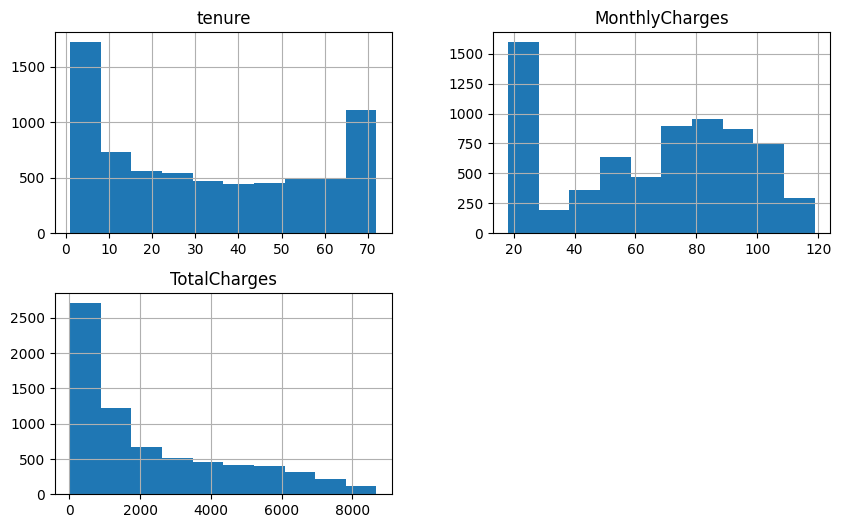

In [ ]:
df[num_cols].hist(figsize=(10,6))
plt.show()

*   Majority of customers are within the first 2–3 years of tenure.
*   Monthly charges vary widely, enabling pricing-based segmentation.
*   Revenue contribution is highly skewed toward long-term customers.

### Churn vs Tenure and Monthly charges

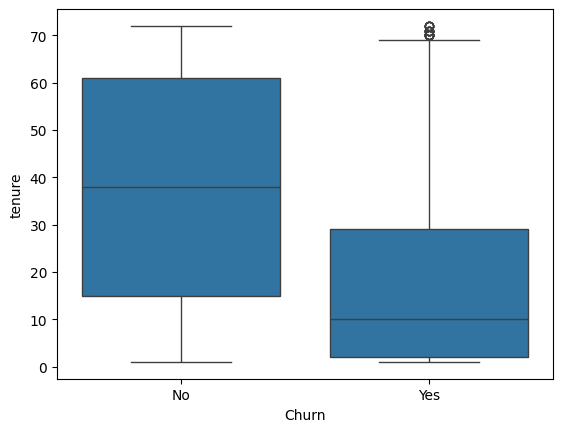

In [ ]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

*   Low tenure customers churn more.



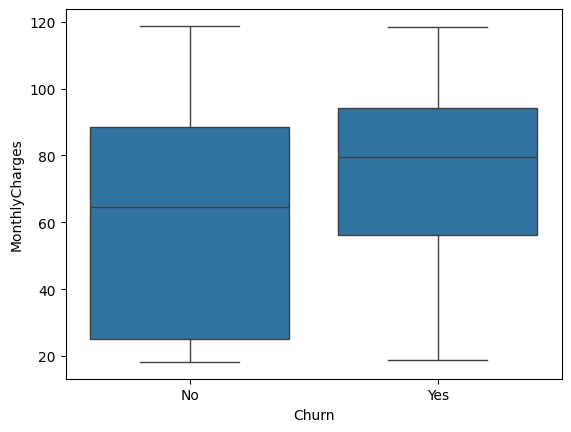

In [ ]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

*   High-paying customers are more likely to churn

### Categorical features vs Churn

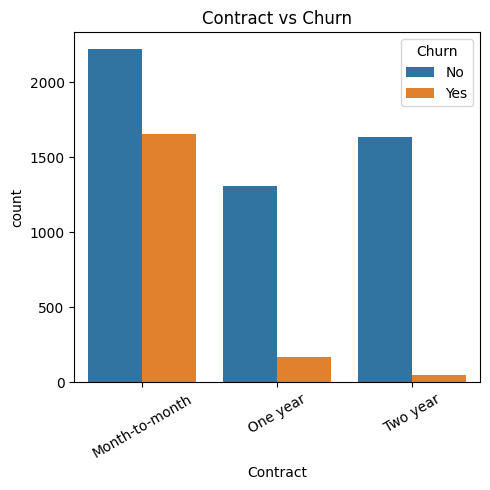

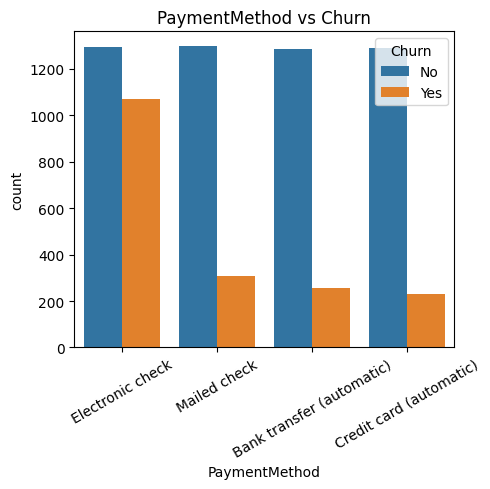

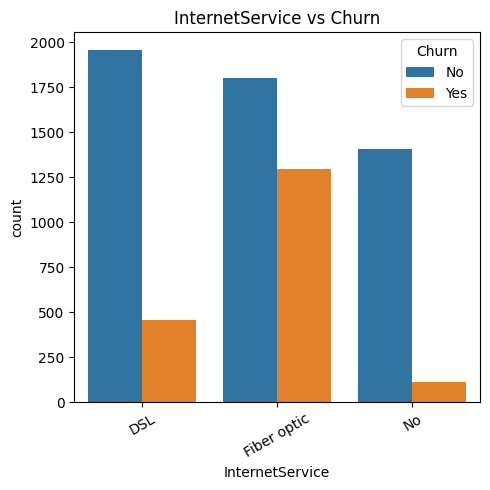

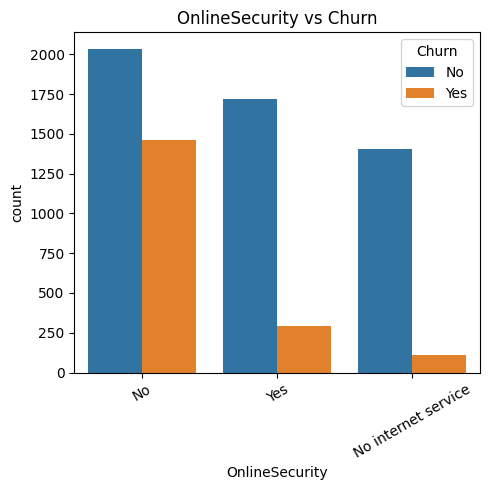

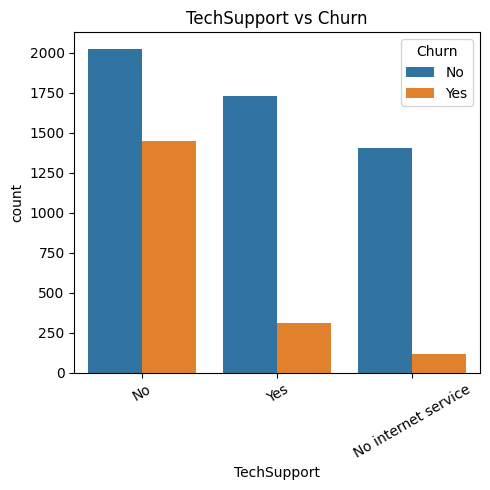

In [ ]:
cat_cols = [
    "Contract", "PaymentMethod",
    "InternetService", "OnlineSecurity",
    "TechSupport"
]

for col in cat_cols:
    plt.figure(figsize=(5, 5))
    sns.countplot(data=df, x=col, hue="Churn")
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

*   Month-to-month contracts show high churn.
*   No OnlineSecurity / TechSupport show high churn.
*   Fiber optic shows higher churn than DSL.
*   Customers using electronic check exhibit higher churn, likely due to lower commitment, manual payment friction, and association with month-to-month contracts.

### Correlation heatmap

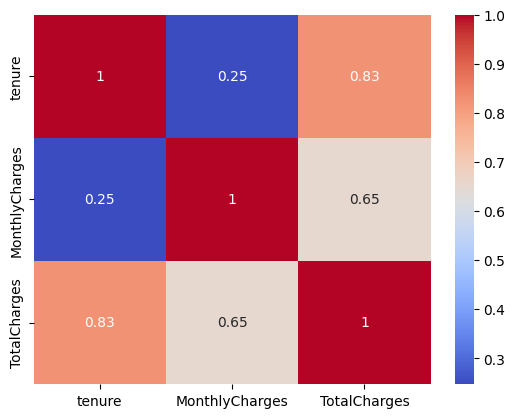

In [ ]:
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

The correlation heatmap was used to identify linear dependencies among numerical features. As expected, tenure and total charges showed a strong correlation due to their mathematical relationship, while monthly charges showed moderate correlation with total charges. No strong multicollinearity was observed beyond this expected dependency.

## EDA Key Findings

*   Customers with short tenure are more likely to churn.
*   Month-to-month contracts show the highest churn rates.
*   Higher monthly charges correlate with higher churn.
*   Lack of support services increases churn risk.

# Feature Engineering and Encoding

In [ ]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
cat_cols = df.select_dtypes(include="object").columns.drop("Churn")

In [ ]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [ ]:
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"].map({"Yes": 1, "No": 0})

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_seg = StandardScaler()
X_segmentation = scaler_seg.fit_transform(X)

In [ ]:
X_churn = X.copy()
scaler_churn = StandardScaler()
X_churn[num_cols] = scaler_churn.fit_transform(X_churn[num_cols])

# Customer Segmentation

## Goal : Group telecom customers into distinct segments based on usage, billing, and service characteristics to enable targeted retention and marketing strategies.

### Why K-Means?

### Scales well to large datasets

### Works well with standardized numerical data

### Produces interpretable, compact clusters

### Industry-standard for customer segmentation

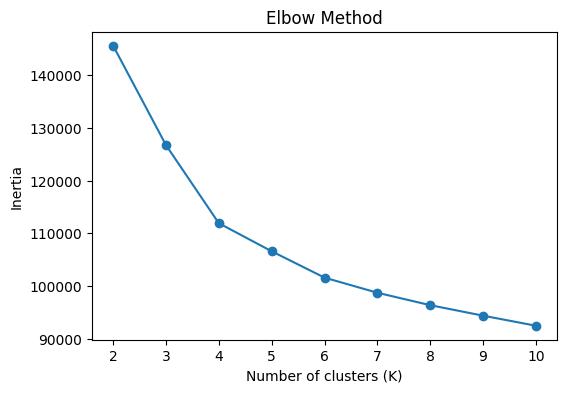

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_segmentation)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

*   The elbow method indicates diminishing returns beyond K=4
*   K=4 captures major customer structure without over-fragmentation
*   Higher K values reduce inertia only marginally

In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = {}

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_segmentation)
    sil_scores[k] = silhouette_score(X_segmentation, labels)

sil_scores

{2: np.float64(0.33510045574519265),
 3: np.float64(0.21938756320600342),
 4: np.float64(0.2390996613535271),
 5: np.float64(0.19250222616017082),
 6: np.float64(0.19429701352459597)}

Although K=2 achieved the highest silhouette score, it resulted in overly coarse segmentation.
K=4 was selected as it balances cluster compactness, interpretability, and business usefulness, consistent with the elbow method.

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["Segment"] = kmeans.fit_predict(X_segmentation)

In [ ]:
df["Segment"].value_counts(normalize=True)

,proportion
Segment,
2,0.389078
0,0.298066
1,0.216155
3,0.096701


*   Customer distribution across four segments is well-balanced
*   No segment is excessively small or dominant
*   Segmentation is suitable for targeted business strategies

In [ ]:
segment_profile = df.groupby("Segment").agg({
    "tenure": "mean",
    "MonthlyCharges": "mean",
    "TotalCharges": "mean",
    "SeniorCitizen": "mean",
    "Churn": lambda x: (x == "Yes").mean()
})

segment_profile

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
Segment,,,,,
0,55.891221,91.899857,5159.003531,0.188931,0.147424
1,30.667763,21.076283,665.220329,0.034211,0.074342
2,15.563596,73.994170,1173.781963,0.215643,0.466740
3,31.830882,41.992500,1500.433750,0.152941,0.250000


*   Four distinct customer segments were identified using K-Means

*   High-value long-tenure customers exhibit low churn

*   New customers with high monthly charges show the highest churn risk

*   Segmentation enables targeted, cost-effective retention strategies

In [ ]:
segment_names = {
    0: "High-Value Loyal",
    1: "Low-Usage Stable",
    2: "High-Risk High-Cost",
    3: "Mid-Tier Transitional"
}

df["Segment_Name"] = df["Segment"].map(segment_names)

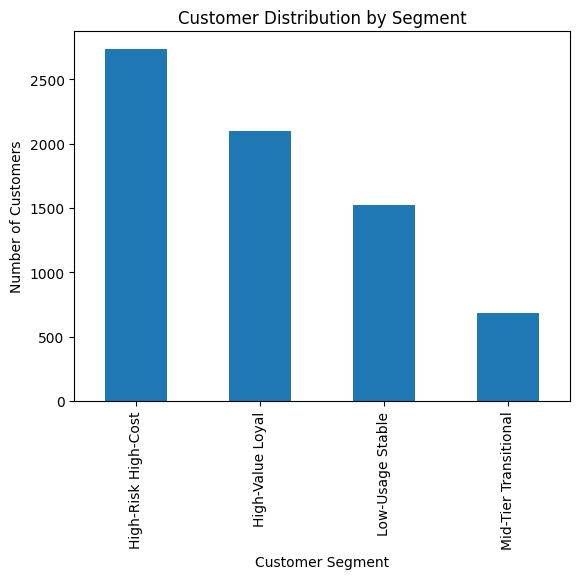

In [ ]:
df["Segment_Name"].value_counts().plot(kind="bar")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Segment")
plt.show()

In [ ]:
df["Churn_Num"] = df["Churn"].map({"Yes": 1, "No": 0})

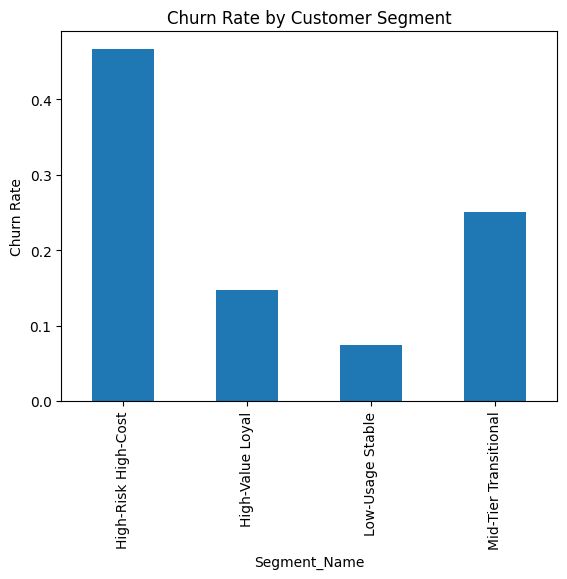

In [ ]:
df.groupby("Segment_Name")["Churn_Num"].mean().plot(kind="bar")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Customer Segment")
plt.show()

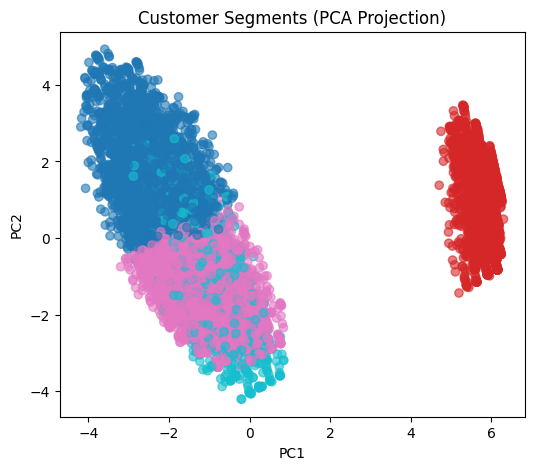

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_segmentation)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Segment"], cmap="tab10", alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments (PCA Projection)")
plt.show()

Principal Component Analysis was applied to visualize customer segments in reduced dimensions. The first two components captured the dominant variance in customer behavior, primarily driven by tenure, billing amounts, and contract characteristics. The resulting PCA plot showed clear separation between customer segments, validating the effectiveness of the clustering approach.

In [ ]:
pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=["PC1", "PC2"]
)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
PC1,-0.072091,-0.071183,-0.282509,-0.184941,0.003120,-0.025768,0.040656,0.029910,-0.029910,-0.111162,...,0.302377,-0.179026,0.302377,-0.180082,-0.002278,0.036641,-0.119469,-0.013650,-0.093990,0.131977
PC2,-0.059321,0.438529,0.083551,0.376584,-0.002242,0.261038,0.185434,0.116354,-0.116354,0.184522,...,0.117569,0.142388,0.117569,0.142780,0.095634,0.352863,-0.064301,0.183299,-0.213504,-0.055188


*   PC1 captures differences in service adoption and revenue contribution

*   PC2 captures customer stability, tenure, and contract commitment

*   Clear separation in PCA space confirms meaningful customer segments
*   PCA supports segmentation interpretability without using churn labels

# Segment profiling and interpretation

In [ ]:
df["Segment"] = kmeans.labels_

In [ ]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]

segment_num_profile = (
    df.groupby("Segment_Name")[num_cols]
      .agg(["mean", "median"])
      .round(2)
)

segment_num_profile

tenure        MonthlyCharges        TotalCharges  \
                        mean median           mean median         mean   
Segment_Name                                                             
High-Risk High-Cost    15.56   11.0          73.99  75.22      1173.78   
High-Value Loyal       55.89   60.0          91.90  94.62      5159.00   
Low-Usage Stable       30.67   25.0          21.08  20.15       665.22   
Mid-Tier Transitional  31.83   29.0          41.99  40.55      1500.43   

                               SeniorCitizen         
                        median          mean median  
Segment_Name                                         
High-Risk High-Cost     834.18          0.22    0.0  
High-Value Loyal       5220.98          0.19    0.0  
Low-Usage Stable        523.67          0.03    0.0  
Mid-Tier Transitional  1153.80          0.15    0.0

In [ ]:
df.groupby("Segment_Name")["Contract"].value_counts(normalize=True)

Segment_Name           Contract      
High-Risk High-Cost    Month-to-month    0.911915
                       One year          0.079313
                       Two year          0.008772
High-Value Loyal       Two year          0.414599
                       One year          0.356393
                       Month-to-month    0.229008
Low-Usage Stable       Two year          0.416447
                       Month-to-month    0.344737
                       One year          0.238816
Mid-Tier Transitional  Month-to-month    0.552941
                       Two year          0.233824
                       One year          0.213235
Name: proportion, dtype: float64

In [ ]:
df.groupby("Segment_Name")["InternetService"].value_counts(normalize=True)

Segment_Name           InternetService
High-Risk High-Cost    Fiber optic        0.648026
                       DSL                0.351974
High-Value Loyal       Fiber optic        0.631202
                       DSL                0.368798
Low-Usage Stable       No                 1.000000
Mid-Tier Transitional  DSL                1.000000
Name: proportion, dtype: float64

In [ ]:
support_cols = ["OnlineSecurity", "TechSupport"]

for col in support_cols:
    print(f"\n{col}")
    print(df.groupby("Segment_Name")[col].value_counts(normalize=True))


OnlineSecurity
Segment_Name           OnlineSecurity     
High-Risk High-Cost    No                     0.801535
                       Yes                    0.198465
High-Value Loyal       Yes                    0.568225
                       No                     0.431775
Low-Usage Stable       No internet service    1.000000
Mid-Tier Transitional  No                     0.586765
                       Yes                    0.413235
Name: proportion, dtype: float64

TechSupport
Segment_Name           TechSupport        
High-Risk High-Cost    No                     0.815789
                       Yes                    0.184211
High-Value Loyal       Yes                    0.595897
                       No                     0.404103
Low-Usage Stable       No internet service    1.000000
Mid-Tier Transitional  No                     0.577941
                       Yes                    0.422059
Name: proportion, dtype: float64


In [ ]:
df.groupby("Segment_Name")["PaymentMethod"].value_counts(normalize=True)

Segment_Name           PaymentMethod            
High-Risk High-Cost    Electronic check             0.532164
                       Mailed check                 0.195906
                       Bank transfer (automatic)    0.146930
                       Credit card (automatic)      0.125000
High-Value Loyal       Credit card (automatic)      0.331584
                       Bank transfer (automatic)    0.317748
                       Electronic check             0.267653
                       Mailed check                 0.083015
Low-Usage Stable       Mailed check                 0.483553
                       Bank transfer (automatic)    0.218421
                       Credit card (automatic)      0.217763
                       Electronic check             0.080263
Mid-Tier Transitional  Electronic check             0.332353
                       Mailed check                 0.233824
                       Credit card (automatic)      0.225000
                       Bank transfer (automatic)    0.208824
Name: proportion, dtype: float64

In [ ]:
segment_summary = df.groupby("Segment_Name").agg(
    Avg_Tenure=("tenure", "mean"),
    Avg_Monthly_Charges=("MonthlyCharges", "mean"),
    Avg_Total_Charges=("TotalCharges", "mean"),
    Churn_Rate=("Churn", lambda x: (x == "Yes").mean())
).round(2)

segment_summary

,Avg_Tenure,Avg_Monthly_Charges,Avg_Total_Charges,Churn_Rate
Segment_Name,,,,
High-Risk High-Cost,15.56,73.99,1173.78,0.47
High-Value Loyal,55.89,91.90,5159.00,0.15
Low-Usage Stable,30.67,21.08,665.22,0.07
Mid-Tier Transitional,31.83,41.99,1500.43,0.25


After clustering, segment profiling was performed using group-wise aggregation to understand average customer characteristics. This enabled interpretation of each segment in terms of tenure, spending behavior, and churn propensity

# Churn Modeling

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Segment,Segment_Name,Churn_Num
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,3,Mid-Tier Transitional,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,No,2,High-Risk High-Cost,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,2,High-Risk High-Cost,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,3,Mid-Tier Transitional,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2,High-Risk High-Cost,1


In [ ]:
X = model_df.drop(columns=["Churn", "Segment_Name", "Churn_Num"])
y = model_df["Churn_Num"]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC: 0.8366097913247849


In [ ]:
segment_coef = pd.Series(
    log_model.coef_[0],
    index=X.columns
).sort_values()

segment_coef.tail(10)

,0
PaymentMethod_Credit card (automatic),0.053654
PaymentMethod_Mailed check,0.081201
StreamingMovies_Yes,0.166295
StreamingTV_Yes,0.192908
SeniorCitizen,0.199967
MultipleLines_No phone service,0.254429
MultipleLines_Yes,0.276575
PaperlessBilling_Yes,0.293660
PaymentMethod_Electronic check,0.390872
InternetService_Fiber optic,0.666733


InternetService_Fiber optic (0.67)
*   Strongest churn predictor
*   Fiber customers pay more → higher price sensitivity


---


PaymentMethod_Electronic check (0.39)

Customers using electronic check churn significantly more

Often linked to:
*   Manual Payment
*   Less Commitment
*   Higher missed-payment probability


---


PaperlessBilling_Yes (0.29)
*   Indicates digitally active but less loyal users
*   Often overlaps with month-to-month contracts

MultipleLines_Yes / No phone service (0.27 / 0.25)

*   Multi-line users face higher bills
*   No-phone-service users are often internet-only, easier to switch providers


---


SeniorCitizen (0.20)

Seniors show slightly higher churn likely due to:

*   Price sensitivity
*   Lower tech stickiness

StreamingTV_Yes / StreamingMovies_Yes (0.19 / 0.17)
*   Entertainment add-ons increase cost
*   If perceived value is low → churn risk rises


---


PaymentMethod_Mailed check (0.08)
*   Weak effect, but still higher churn than auto-pay


---


PaymentMethod_Credit card (automatic) (0.05)
*   Near-zero, most stable payment method

Payment method and internet service type are stronger churn predictors than demographic features, indicating that billing behavior and service cost play a more significant role in customer retention.